DATA PREPROCESSING AND EXPLORATION:

1. Loaded the dataset.
2. Preprocessed.
3. Explored.
4. Split the data into train/test(80/20).


Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            0.428704          0.440556           0.467458   
std             0.230018          0.181611           0.299203   
min             0.000000          0.000000           0.000000   
25%             0.222222          0.333333           0.101695   
50%             0.416667          0.416667           0.567797   
75%             0.583333          0.541667           0.694915   
max             1.000000          1.000000           1.000000   

       petal width (cm)      target  target_encoded  
count        150.000000  150.000000      150.000000  
mean           0.458056    1.000000        1.000000  
std            0.317599    0.819232        0.819232  

/Users/chadmutinda/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/Users/chadmutinda/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


Error saving boxplots: 'SubplotSpec' object has no attribute 'is_first_col'

Train shape: (120, 4), Test shape: (30, 4)


<Figure size 720x432 with 0 Axes>

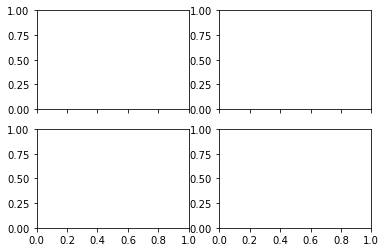

In [6]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Create visualizations directory if not exists
os.makedirs('visualizations', exist_ok=True)

def load_data():
    iris = load_iris()
    df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                      columns=iris['feature_names'] + ['target'])
    df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
    return df

def preprocess_data(df):
    print("Missing values per column:")
    print(df.isnull().sum())
    
    scaler = MinMaxScaler()
    features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
    df[features] = scaler.fit_transform(df[features])
    
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['species'])
    return df

def explore_data(df):
    print("\nSummary Statistics:")
    print(df.describe())
    
    # Pairplot with error handling
    try:
        sns.pairplot(df, hue='species', markers=['o', 's', 'D'])
        plt.savefig('visualizations/iris_pairplot.png', bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"Error saving pairplot: {e}")
    
    # Heatmap
    try:
        plt.figure(figsize=(8,6))
        sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
        plt.title('Feature Correlation Heatmap')
        plt.savefig('visualizations/iris_heatmap.png', bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"Error saving heatmap: {e}")
    
    # Boxplots
    try:
        plt.figure(figsize=(10,6))
        df.boxplot(column=['sepal length (cm)', 'sepal width (cm)', 
                         'petal length (cm)', 'petal width (cm)'], by='species')
        plt.suptitle('')
        plt.savefig('visualizations/iris_boxplots.png', bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"Error saving boxplots: {e}")

def split_data(df, test_size=0.2, random_state=42):
    X = df[['sepal length (cm)', 'sepal width (cm)', 
            'petal length (cm)', 'petal width (cm)']]
    y = df['target_encoded']
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

if __name__ == "__main__":
    df = load_data()
    df = preprocess_data(df)
    explore_data(df)
    X_train, X_test, y_train, y_test = split_data(df)
    print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")